Import the required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import scipy.stats as stats
from statsmodels.formula.api import ols
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
le =  LabelEncoder()
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings('ignore')

In [3]:
data =  pd.read_csv("Health_insurance.csv")

Description of the Data:

Age - This is an integer indicating the age of the primary beneficiary (excluding those above 64 years, since they are generally covered by the government).

Sex - This is the policy holder's gender, either male or female.

BMI - This is the body mass index (BMI), which provides a sense of how over or under-weight a person is relative to their height. BMI is equal to weight (in kilograms) divided by height (in meters) squared. An ideal BMI is within the range of 18.5 to 24.9.

Children - This is an integer indicating the number of children / dependents covered by the insurance plan.

Smoker - This is yes or no depending on whether the insured regularly smoke" tobacco.

Region - This is the beneficiary's place of residence in the U.S., divided into four geographic regions - northeast, southeast, southwest, or northwest.

Charges - Individual medical costs billed to health insurance.



In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Check for any missing data and if needed we need to fill the missing data or remove it depending on the quantity of missing data. In addition also check for any duplicates in the data

In [5]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data.duplicated().sum()

1

In [7]:
data =  data.drop_duplicates()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [9]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


Check for any outliers in the data as this can lead to skewing the model

<Axes: xlabel='children'>

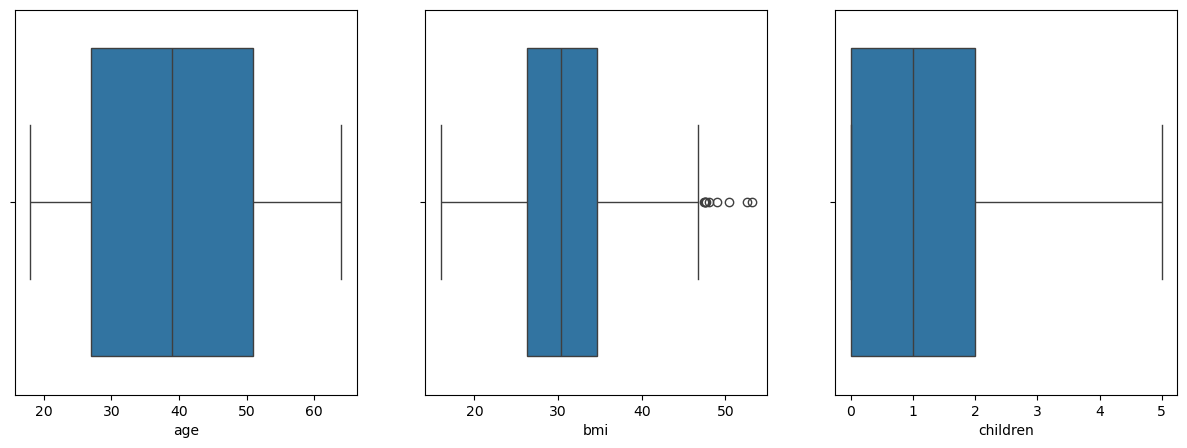

In [10]:
fig,ax  = plt.subplots(1,3,figsize=(15,5))
sns.boxplot(data=data, x = 'age', ax = ax[0])
sns.boxplot(data=data, x = 'bmi', ax = ax[1])
sns.boxplot(data=data, x = 'children', ax = ax[2])

### Univariate Analysis

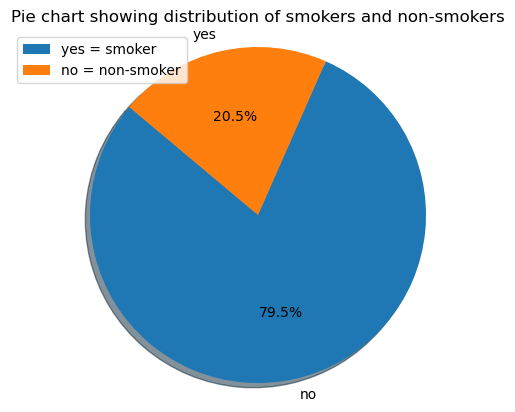

In [12]:
sizes = data["smoker"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of smokers and non-smokers")
plt.axis('equal')
plt.legend(["yes = smoker","no = non-smoker"])
plt.show()

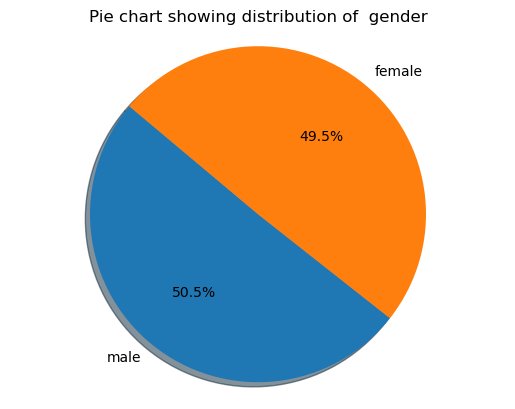

In [12]:
sizes = data["sex"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of  gender")
plt.axis('equal')
plt.show()

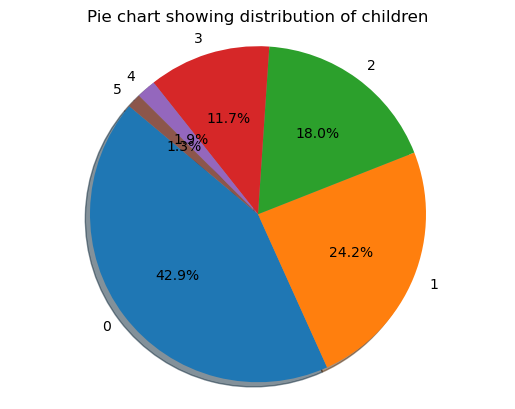

In [11]:
sizes = data["children"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of children")
plt.axis('equal')
plt.show()

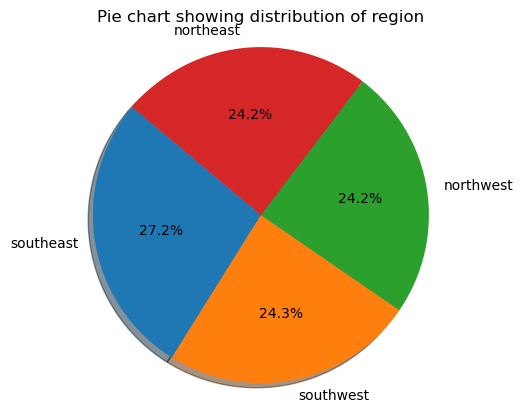

In [13]:
sizes = data["region"].value_counts()
# Plot
plt.pie(sizes.values, labels=sizes.index, 
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title("Pie chart showing distribution of region")
plt.axis('equal')
plt.show()

<Axes: xlabel='sex', ylabel='charges'>

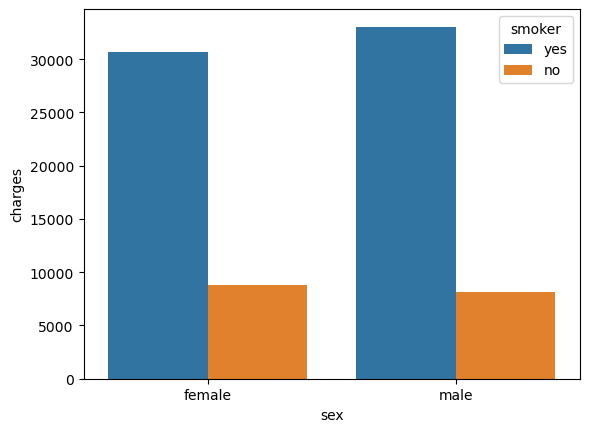

In [36]:
sns.barplot(data=data, x = 'sex', y= 'charges', hue='smoker',ci=False)

Check the distribution of the dataset based on the sex

<Axes: xlabel='smoker', ylabel='Count'>

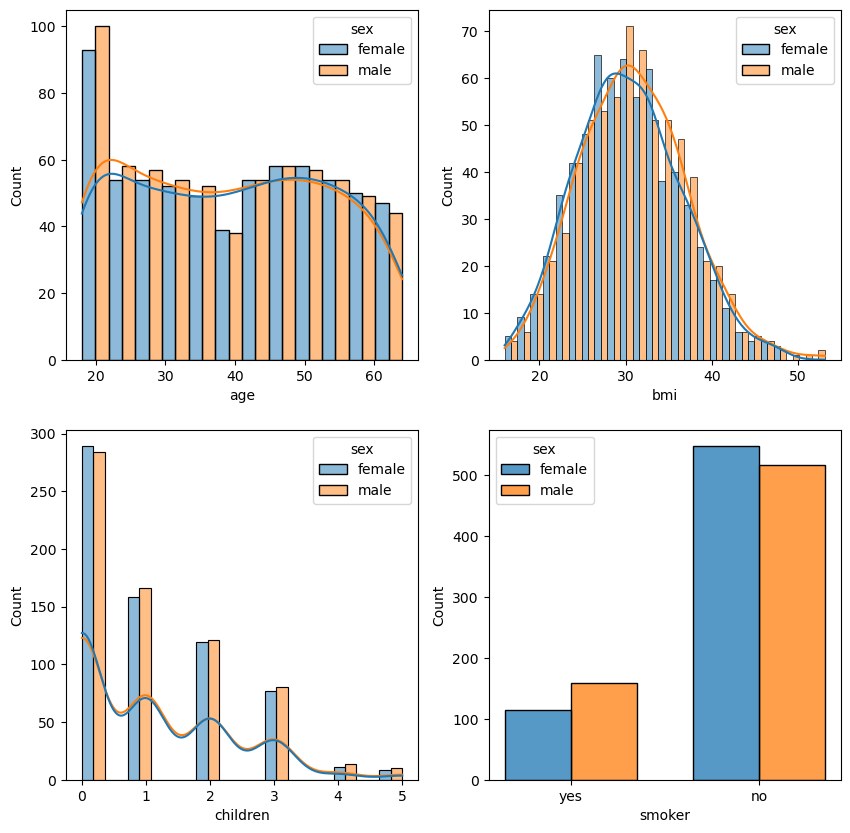

In [16]:
fig,ax  = plt.subplots(2,2,figsize=(10,10))
sns.histplot(data=data, x='age', hue = 'sex', ax = ax[0][0], multiple='dodge', kde=True)
sns.histplot(data=data, x='bmi', hue = 'sex', ax = ax[0][1], multiple='dodge', kde=True)
sns.histplot(data=data, x='children', hue = 'sex', ax = ax[1][0], multiple='dodge', kde=True)
sns.histplot(data=data, x='smoker', hue = 'sex', ax = ax[1][1], multiple='dodge', shrink=0.7)

In [17]:
data.groupby(by='sex')[['charges','bmi','age']].agg(["mean","count"])

charges              bmi              age      
                mean count       mean count       mean count
sex                                                         
female  12569.578844   662  30.377749   662  39.503021   662
male    13974.998864   675  30.943652   675  38.946667   675

In [18]:
male_charge =  data[data['sex']=='male']['charges']
female_charge = data[data['sex']=='female']['charges']

stat,p = stats.ttest_ind(male_charge,female_charge, alternative='greater')

H0 = "There is no significant difference between the charges between men and women"
H1 = "There is a difference between the charges for men and women"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  0.01691039599755975
We reject the null hypothesis
There is a difference between the charges for men and women


In [19]:
male_bmi =  data[data['sex']=='male']['bmi']
female_bmi = data[data['sex']=='female']['bmi']

stat,p = stats.ttest_ind(male_bmi,female_bmi)

H0 = "There is no significant difference between the bmi between men and women"
H1 = "There is a difference between the bmi for men and women"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  0.08991704324931137
The null hypothesis cannot be rejected
There is no significant difference between the bmi between men and women


In [20]:
data.groupby(by='smoker')[['charges','bmi','age']].agg(["mean","count"])

charges              bmi              age      
                mean count       mean count       mean count
smoker                                                      
no       8440.660307  1063  30.651853  1063  39.404516  1063
yes     32050.231832   274  30.708449   274  38.514599   274

In [21]:
smoker_charge =  data[data['smoker']=='yes']['charges']
no_smoker_charge = data[data['smoker']=='no']['charges']

stat,p = stats.ttest_ind(smoker_charge,no_smoker_charge, alternative='greater')

H0 = "There is no significant difference between the charges between smokers  and non smokers"
H1 = "There is a an increase in the charges for smoker when compared to non smokers"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  7.033610474688249e-283
We reject the null hypothesis
There is a an increase in the charges for smoker when compared to non smokers


In [22]:
smoker_bmi =  data[data['smoker']=='yes']['bmi']
no_smoker_bmi = data[data['smoker']=='no']['bmi']

stat,p = stats.ttest_ind(smoker_bmi,no_smoker_bmi, alternative='greater')

H0 = "There is no significant difference between the bmi between smokers  and non smokers"
H1 = "There is a an increase in the bmi for smoker when compared to non smokers"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  0.4455735658611427
The null hypothesis cannot be rejected
There is no significant difference between the bmi between smokers  and non smokers


In [23]:
smoker_age =  data[data['smoker']=='yes']['age']
no_smoker_age = data[data['smoker']=='no']['age']

stat,p = stats.ttest_ind(smoker_charge,no_smoker_charge)

H0 = "There is no significant difference between the age of smokers  and non smokers"
H1 = "There is a difference between the age of smokers  and non smokers"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  1.4067220949376498e-282
We reject the null hypothesis
There is a difference between the age of smokers  and non smokers


<Axes: xlabel='sex', ylabel='bmi'>

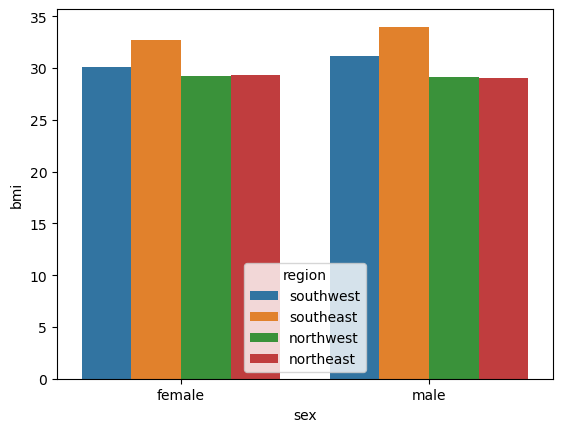

In [41]:
sns.barplot(data=data, x = 'sex', y= 'bmi', hue='region',ci=False)

<Axes: xlabel='sex', ylabel='charges'>

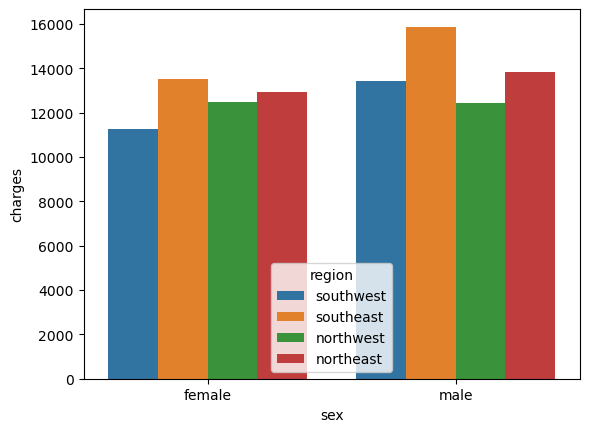

In [37]:
sns.barplot(data=data, x = 'sex', y= 'charges', hue='region',ci=False)

<Axes: xlabel='age', ylabel='charges'>

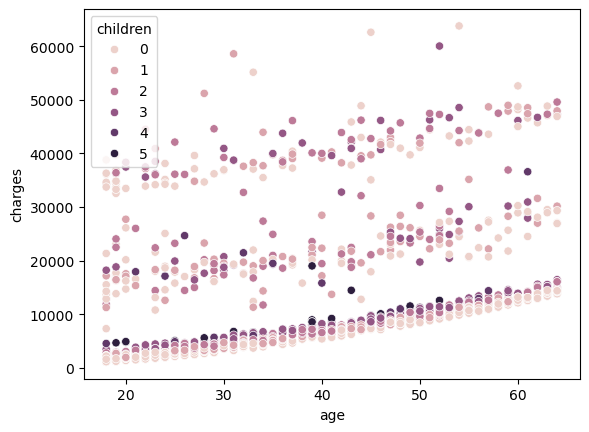

In [40]:
sns.scatterplot(data=data, x = 'age', y = 'charges', hue = 'children')

<Axes: xlabel='age', ylabel='charges'>

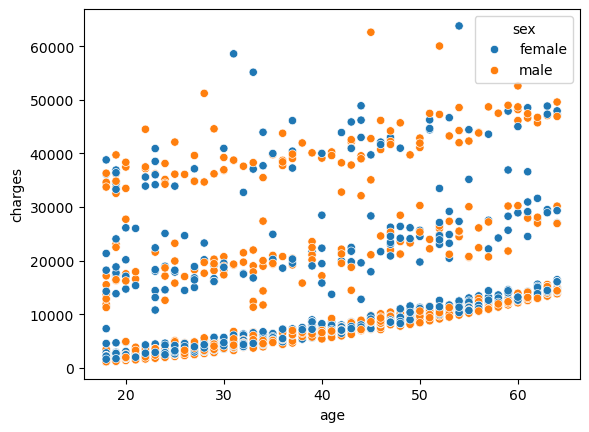

In [38]:
sns.scatterplot(data=data, x = 'age', y = 'charges', hue = 'sex')

In [24]:
data.groupby(by='region')[['charges','bmi','age']].agg(["mean","count"])

charges              bmi              age      
                   mean count       mean count       mean count
region                                                         
northeast  13406.384516   324  29.173503   324  39.268519   324
northwest  12450.840844   324  29.195494   324  39.259259   324
southeast  14735.411438   364  33.355989   364  38.939560   364
southwest  12346.937377   325  30.596615   325  39.455385   325

In [25]:
data.groupby(by='children')[['charges','bmi','age']].agg(["mean","count"])

charges              bmi              age      
                  mean count       mean count       mean count
children                                                      
0         12384.695344   573  30.550227   573  38.478185   573
1         12731.171832   324  30.623148   324  39.453704   324
2         15073.563734   240  30.978104   240  39.445833   240
3         15355.318367   157  30.684331   157  41.566879   157
4         13850.656311    25  31.391200    25  39.000000    25
5          8786.035247    18  29.605000    18  35.611111    18

In [27]:
smoker_charge =  data[data['smoker']=='yes']['bmi']
no_smoker_charge = data[data['smoker']=='no']['bmi']

stat,p = stats.ttest_ind(smoker_charge,no_smoker_charge)

H0 = "There is no significant difference between the bmi of smokers  and non smokers"
H1 = "There is  significant difference between the bmi of smokers  and non smokers"
if p > 0.05:
    print('P Value : ', p)
    print("The null hypothesis cannot be rejected")
    print(H0)
else :
    print('P Value : ',p)
    print("We reject the null hypothesis")
    print(H1)

P Value :  0.8911471317222854
The null hypothesis cannot be rejected
There is no significant difference between the bmi of smokers  and non smokers


In [28]:
from scipy.stats import f_oneway
no_children = data[data["children"] == 0]["charges"]
one_children = data[data["children"] == 1]["charges"]
two_children = data[data["children"] == 2]["charges"]
three_children = data[data["children"] == 3]["charges"]
four_children = data[data["children"] == 4]["charges"]
five_children = data[data["children"] == 5]["charges"]
stat,p = f_oneway(no_children,one_children,two_children,three_children,four_children,five_children)
if p > 0.05:
    print('P Value : ',p)
    print("We cannot reject the null hypothesis. The average billing  is not different for all samples")
else:
    print('P Value : ',p)
    print("We can reject the null hypothesis. The average billing is different for samples")

P Value :  0.006133448188169501
We can reject the null hypothesis. The average billing is different for samples


In [29]:
southwest = data[data["region"] == "southwest"]["charges"]
southeast = data[data["region"] == "southeast"]["charges"]
northwest = data[data["region"] == "northwest"]["charges"]
northeast = data[data["region"] == "northeast"]["charges"]

stat,p = f_oneway(southwest,southeast,northwest,northeast)
if p > 0.05:
    print('P Value : ',p)
    print("We cannot reject the null hypothesis. The average charges covered for different regions is same")
else:
    print('P Value : ',p)
    print("We can reject the null hypothesis. The average charges covered for different regions is not same")

P Value :  0.03276288025444947
We can reject the null hypothesis. The average charges covered for different regions is not same


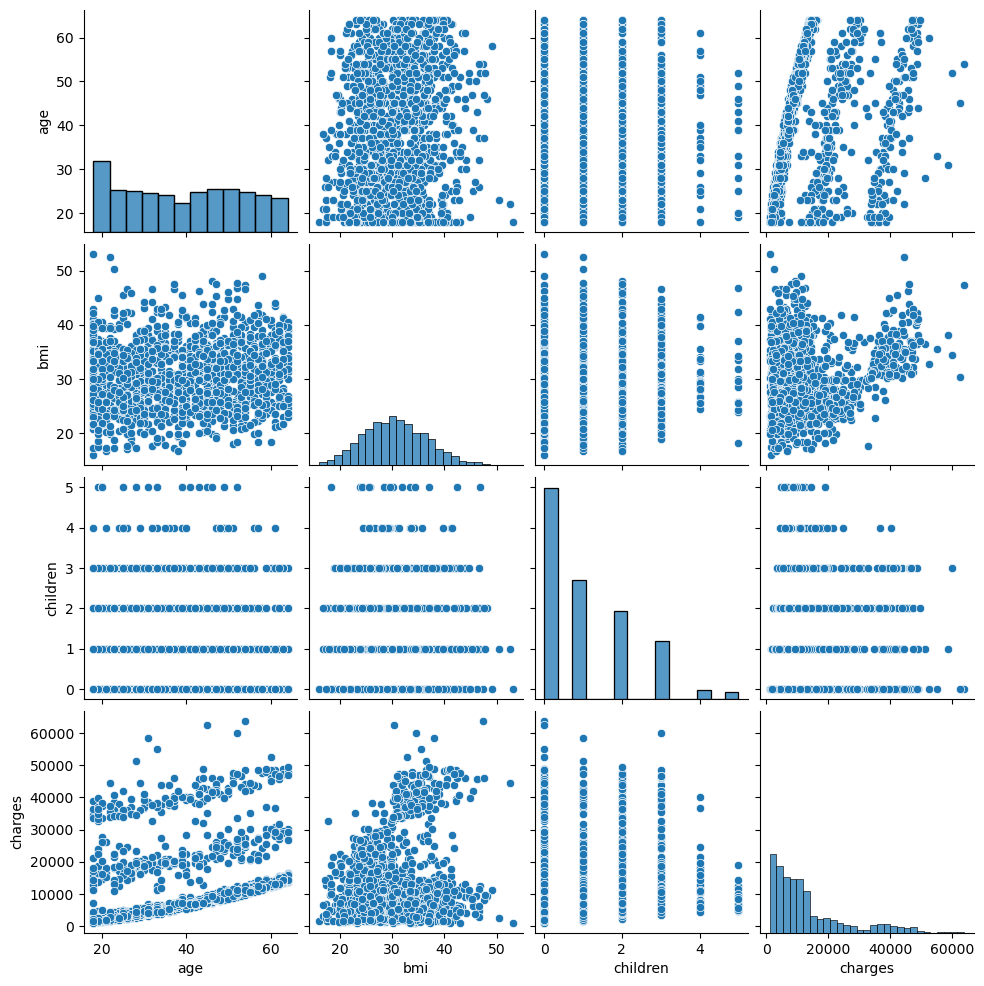

In [30]:
sns.pairplot(data=data)

In [31]:
age = data["age"]
charges = data["charges"]
stat,p = stats.pearsonr(age,charges)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. Age and charges are dependent and have linear relationship")

6.975748762688953e-29
We can reject the null hypothesis. Age and charges are dependent and have linear relationship


In [32]:
bmi = data["bmi"]
charges = data["charges"]
stat,p = stats.pearsonr(bmi,charges)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. Age and charges are dependent and have linear relationship")

2.4680404264511973e-13
We can reject the null hypothesis. Age and charges are dependent and have linear relationship


In [33]:
children = data["children"]
charges = data["charges"]
stat,p = stats.pearsonr(children,charges)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. Age and charges are dependent and have linear relationship")

0.013717026292986234
We can reject the null hypothesis. Age and charges are dependent and have linear relationship


In [34]:
children = data["children"]
age = data["age"]
stat,p = stats.pearsonr(children,age)
if p > 0.05:
    print(p)
    print("We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship")
else:
    print(p)
    print("We can reject the null hypothesis. Age and charges are dependent and have linear relationship")

0.12901275682639754
We cannot reject the null hypothesis. Age and charges are not dependent and have no linear relationship


<Axes: >

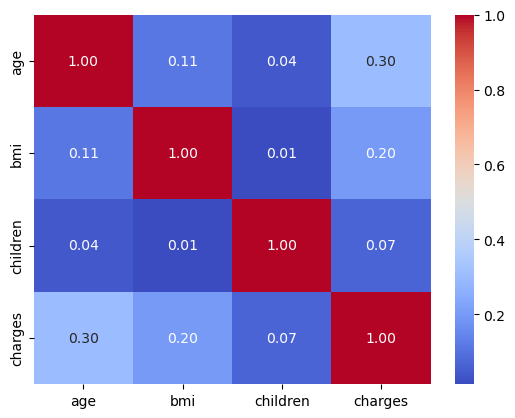

In [35]:
sns.heatmap(data.corr(numeric_only=True), annot= True, cmap='coolwarm', fmt='.2f')

In [43]:
data['sex'] =  le.fit_transform(data['sex'])
data['smoker'] =  le.fit_transform(data['smoker'])
data['region'] =  le.fit_transform(data['region'])

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   int32  
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   int32  
 5   region    1337 non-null   int32  
 6   charges   1337 non-null   float64
dtypes: float64(2), int32(3), int64(2)
memory usage: 67.9 KB


In [45]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [55]:
X = data.drop(columns='charges')
y =  data['charges']

In [57]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, random_state=0)

In [59]:
X_train =  sm.add_constant(X_train)
model =  sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     502.2
Date:                Sat, 12 Apr 2025   Prob (F-statistic):          6.38e-297
Time:                        16:43:53   Log-Likelihood:                -10128.
No. Observations:                1002   AIC:                         2.027e+04
Df Residuals:                     995   BIC:                         2.030e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.06e+04   1094.134     -9.690      0.000   -1.27e+04   -8455.159
age          244.4329     13.432     18.198      0.000     218.075     270.791
sex           27.0954    377.685      0.072      0.943    -714.056     768.247
bmi          303.2148     31.377      9.663      0.000     241.641     364.788
children     484.9719    154.729      3.134      0.002     181.339     788.605
smoker      2.392e+04    471.246     50.764      0.000     2.3e+04    2.48e+04
region      -402.1915    172.370     -2.333      0.020    -740.441     -63.942
==============================================================================
Omnibus:                      257.398   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              729.454
Skew:                           1.293   Prob(JB):                    3.99e-159
Kurtosis:                       6.285   Cond. No.                         300.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
X_test =  sm.add_constant(X_test)
y_pred = model.predict(X_test)

In [61]:
print('r^2 score: ',metrics.r2_score(y_test,y_pred))

print('Mean Absolute Error:',metrics.mean_absolute_error(y_test,y_pred))
print('Mean Square Error:',metrics.mean_squared_error(y_test,y_pred))
print('Root Mean Square Error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

r^2 score:  0.7438474494767136
Mean Absolute Error: 4376.907790239394
Mean Square Error: 40864653.719605416
Root Mean Square Error: 6392.546731906261


In [62]:
X = data.drop(columns=['charges','sex'])
y =  data['charges']

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25, random_state=0)
X_train =  sm.add_constant(X_train)
model =  sm.OLS(y_train,X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     603.2
Date:                Sat, 12 Apr 2025   Prob (F-statistic):          2.48e-298
Time:                        16:44:01   Log-Likelihood:                -10128.
No. Observations:                1002   AIC:                         2.027e+04
Df Residuals:                     996   BIC:                         2.030e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.059e+04   1081.540     -9.792      0.000   -1.27e+04   -8468.257
age          244.4061     13.420     18.212      0.000     218.072     270.741
bmi          303.2984     31.340      9.678      0.000     241.798     364.799
children     485.2741    154.595      3.139      0.002     181.906     788.643
smoker      2.392e+04    470.266     50.873      0.000     2.3e+04    2.48e+04
region      -402.4789    172.237     -2.337      0.020    -740.468     -64.490
==============================================================================
Omnibus:                      257.399   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              729.388
Skew:                           1.293   Prob(JB):                    4.13e-159
Kurtosis:                       6.284   Cond. No.                         296.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
X_test =  sm.add_constant(X_test)
y_pred = model.predict(X_test)

In [66]:
print('r^2 score: ',metrics.r2_score(y_test,y_pred))

print('Mean Absolute Error:',metrics.mean_absolute_error(y_test,y_pred))
print('Mean Square Error:',metrics.mean_squared_error(y_test,y_pred))
print('Root Mean Square Error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))

r^2 score:  0.7438942349767945
Mean Absolute Error: 4375.947394085463
Mean Square Error: 40857189.91237023
Root Mean Square Error: 6391.962915440782
